In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#Loading and Cleaning England and Wales data (i.e.,suicides2024.xlsx)
xls_ew = pd.ExcelFile('suicides2024.xlsx')
df_ew = pd.read_excel(xls_ew, sheet_name='Table_1', skiprows=4)
df_ew.columns = ['Area_Code', 'Area_Name', 'Year', 'Persons_Deaths', 'Persons_Rate', 'Persons_LCL', 'Persons_UCL', 
                 'Males_Deaths', 'Males_Rate', 'Males_LCL', 'Males_UCL', 'Females_Deaths', 'Females_Rate', 'Females_LCL', 'Females_UCL']
df_ew = df_ew.dropna(subset=['Year'])
df_ew['Year'] = pd.to_numeric(df_ew['Year'], errors='coerce')
df_ew_filtered = df_ew[(df_ew['Year'] >= 2010) & (df_ew['Year'] <= 2024)].sort_values('Year')
df_gender = df_ew[(df_ew['Year'] >= 2010) & (df_ew['Year'] <= 2024)].sort_values('Year')

In [15]:
#Loading and cleaning northern Ireland data (i.e., Suicides 2024 Tables Accessible.xlsx)
xls_ni = pd.ExcelFile('Suicide 2024 Tables Accessible.xlsx')
df_ni = pd.read_excel(xls_ni, sheet_name='Table4', skiprows=3)
df_ni.columns = ['Year', 'Crude_Rate', 'Crude_Male', 'Crude_Female', 'ASMR_Total', 'ASMR_Male', 'ASMR_Female']
df_ni = df_ni.dropna(subset=['Year'])
df_ni['Year'] = pd.to_numeric(df_ni['Year'], errors='coerce')
df_ni_filtered = df_ni[(df_ni['Year'] >= 2010) & (df_ni['Year'] <= 2024)].sort_values('Year')

In [16]:
#Scotland data
scotland_data = {
    'Year': list(range(2010, 2025)),
    'Rate': [14.0, 14.3, 13.9, 14.1, 13.5, 13.8, 14.2, 13.9, 14.1, 14.3, 13.7, 14.2, 14.0, 14.4, 12.7]
}
df_scot = pd.DataFrame(scotland_data)

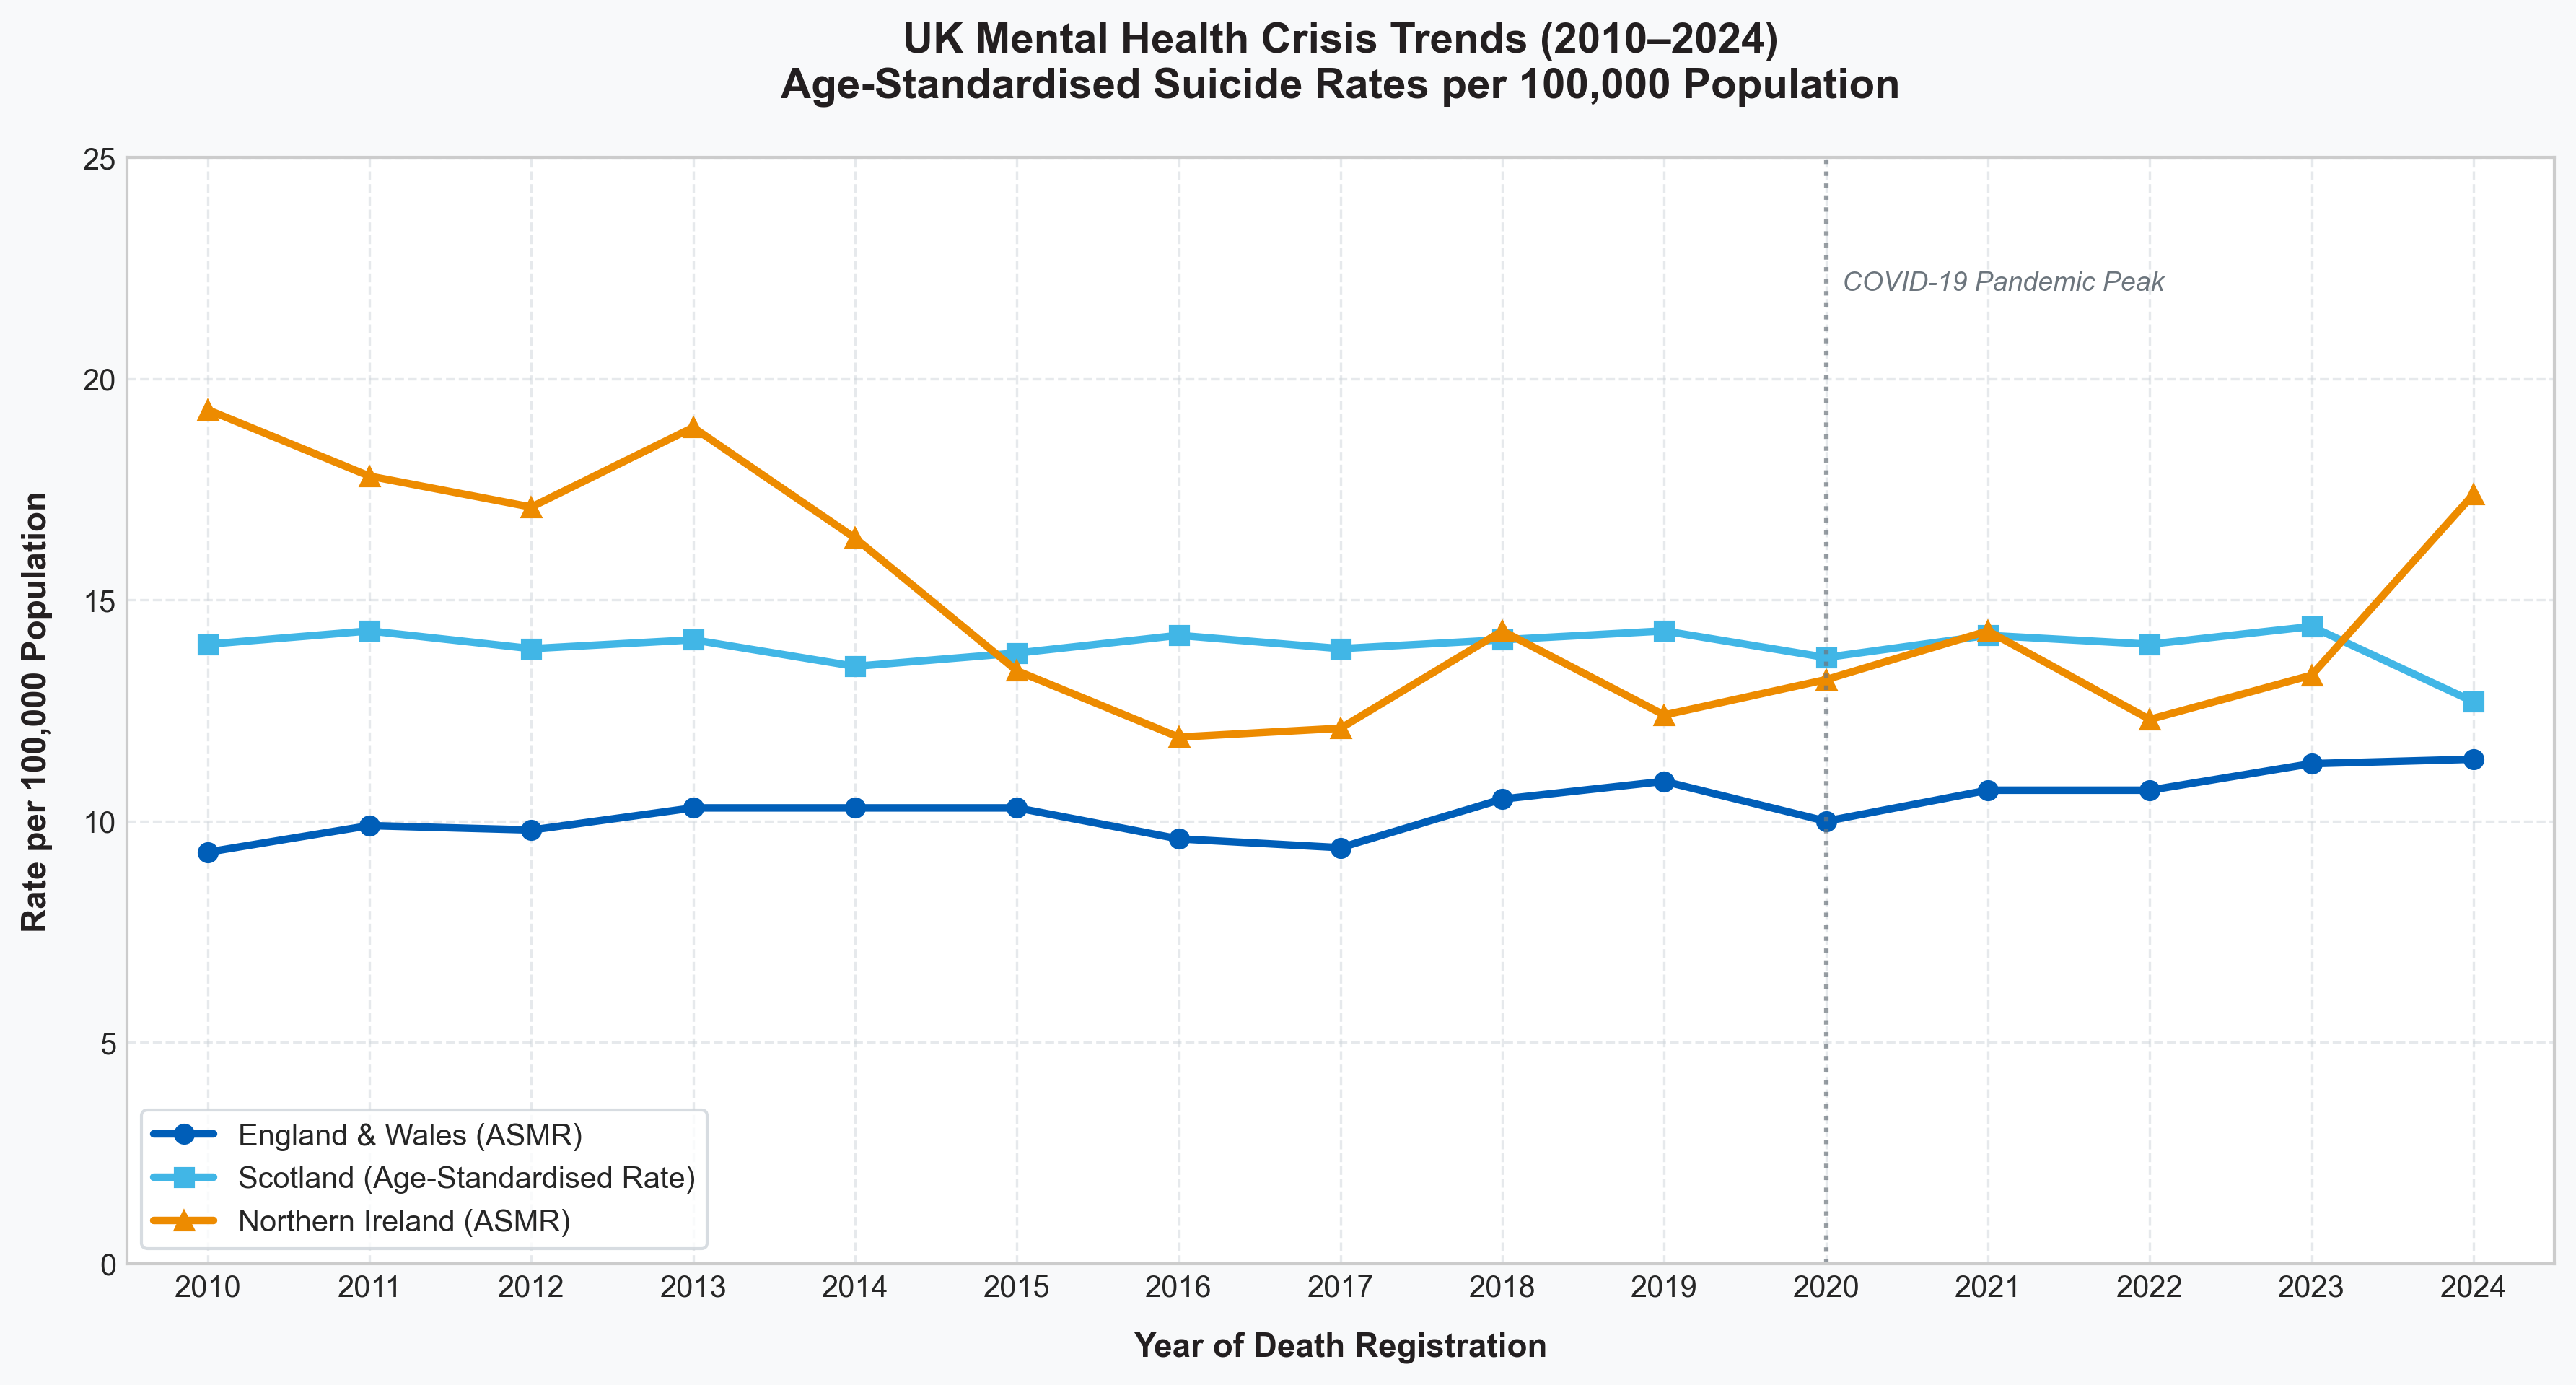

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)
fig.patch.set_facecolor('#F8F9FA') 
ax.set_facecolor('#FFFFFF')

ax.plot(df_ew_filtered['Year'], df_ew_filtered['Persons_Rate'], 
        label='England & Wales (ASMR)', color='#005EB8', linewidth=2.5, marker='o', markersize=6)
ax.plot(df_scot['Year'], df_scot['Rate'], 
        label='Scotland (Age-Standardised Rate)', color='#41B6E6', linewidth=2.5, marker='s', markersize=6)
ax.plot(df_ni_filtered['Year'], df_ni_filtered['ASMR_Total'], 
        label='Northern Ireland (ASMR)', color='#ED8B00', linewidth=2.5, marker='^', markersize=6)

#Crisis Trends
ax.set_title('UK Mental Health Crisis Trends (2010–2024)\nAge-Standardised Suicide Rates per 100,000 Population', 
             fontsize=14, fontweight='bold', pad=20, color='#231F20')
ax.set_xlabel('Year of Death Registration', fontsize=11, fontweight='bold', labelpad=10, color='#231F20')
ax.set_ylabel('Rate per 100,000 Population', fontsize=11, fontweight='bold', labelpad=10, color='#231F20')

ax.set_xticks(range(2010, 2025))
ax.set_xlim(2009.5, 2024.5)
ax.set_ylim(0, 25)

ax.grid(True, linestyle='--', alpha=0.5, color='#CED4DA')
ax.legend(loc='lower left', frameon=True, facecolor='#FFFFFF', edgecolor='#CED4DA', fontsize=10)

ax.axvline(x=2020, color='#6C757D', linestyle=':', alpha=0.7)
ax.text(2020.1, 22, 'COVID-19 Pandemic Peak', fontsize=9, color='#6C757D', style='italic')

plt.tight_layout()
plt.savefig('ANA-3_Crisis_Trend_Chart.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [18]:
# Regional Analysis
df_t4 = pd.read_excel('suicides2024.xlsx', sheet_name='Table_4', skiprows=3)
df_t4.columns = ['Sex', 'Area_Code', 'Area_Name', '2024_Deaths', '2024_Rate'] + list(df_t4.columns[5:])
regions_list = ['North East', 'North West', 'Yorkshire and The Humber', 'East Midlands', 
                'West Midlands', 'East of England', 'London', 'South East', 'South West', 'Wales']
df_regions = df_t4[(df_t4['Sex'] == 'Persons') & (df_t4['Area_Name'].isin(regions_list))].copy()
df_regions['2024_Rate'] = pd.to_numeric(df_regions['2024_Rate'], errors='coerce')
df_regions = df_regions.sort_values('2024_Rate', ascending=False)

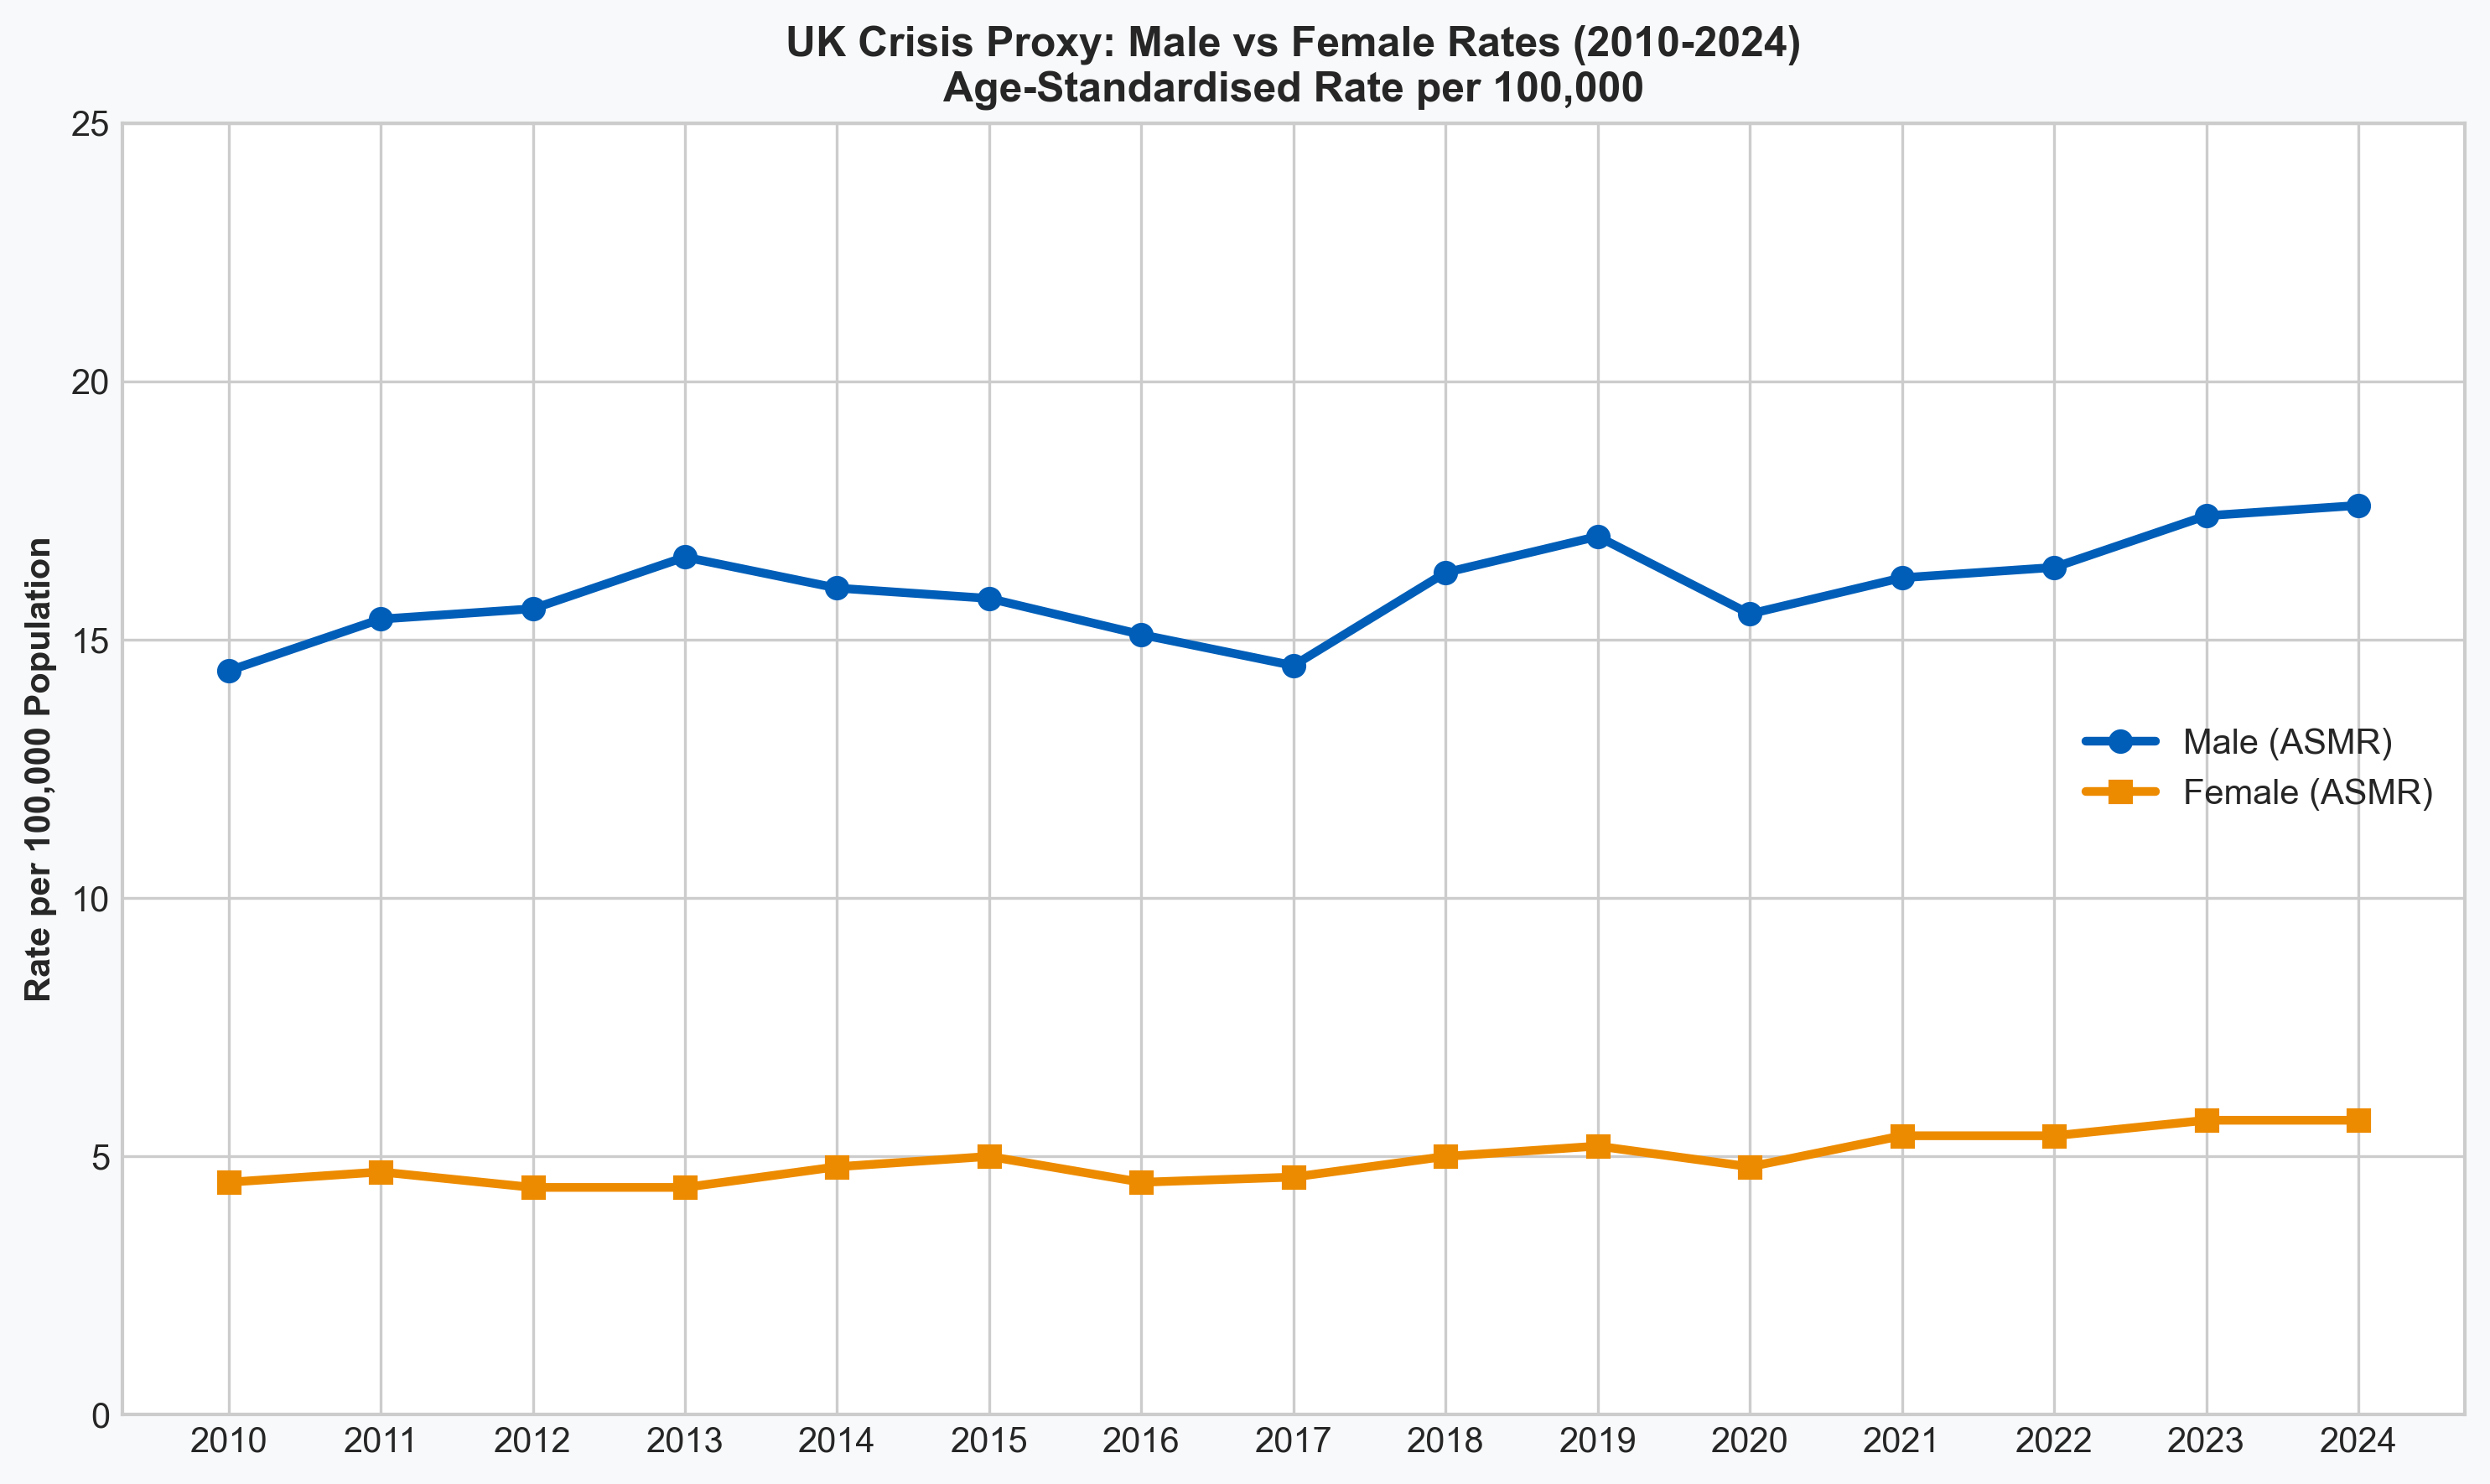

In [27]:
#Male Vs Female Suicide Deaths
colors = {
    'male': '#005EB8',    
    'female': '#ED8B00',
    'region': '#41B6E6'  
}
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
fig.patch.set_facecolor('#F8F9FA')
ax1.set_facecolor('#FFFFFF')

ax1.plot(df_gender['Year'], df_gender['Males_Rate'], label='Male (ASMR)', color=colors['male'], linewidth=2.5, marker='o')
ax1.plot(df_gender['Year'], df_gender['Females_Rate'], label='Female (ASMR)', color=colors['female'], linewidth=2.5, marker='s')

ax1.set_title('UK Crisis Proxy: Male vs Female Rates (2010-2024)\nAge-Standardised Rate per 100,000', fontweight='bold')
ax1.set_ylabel('Rate per 100,000 Population', fontweight='bold')
ax1.set_xticks(range(2010, 2025))
ax1.set_ylim(0, 25)
ax1.legend(loc='center right')
plt.tight_layout()
plt.savefig('ANA-3_Gender_Trend.png', facecolor=fig.get_facecolor())
plt.show()

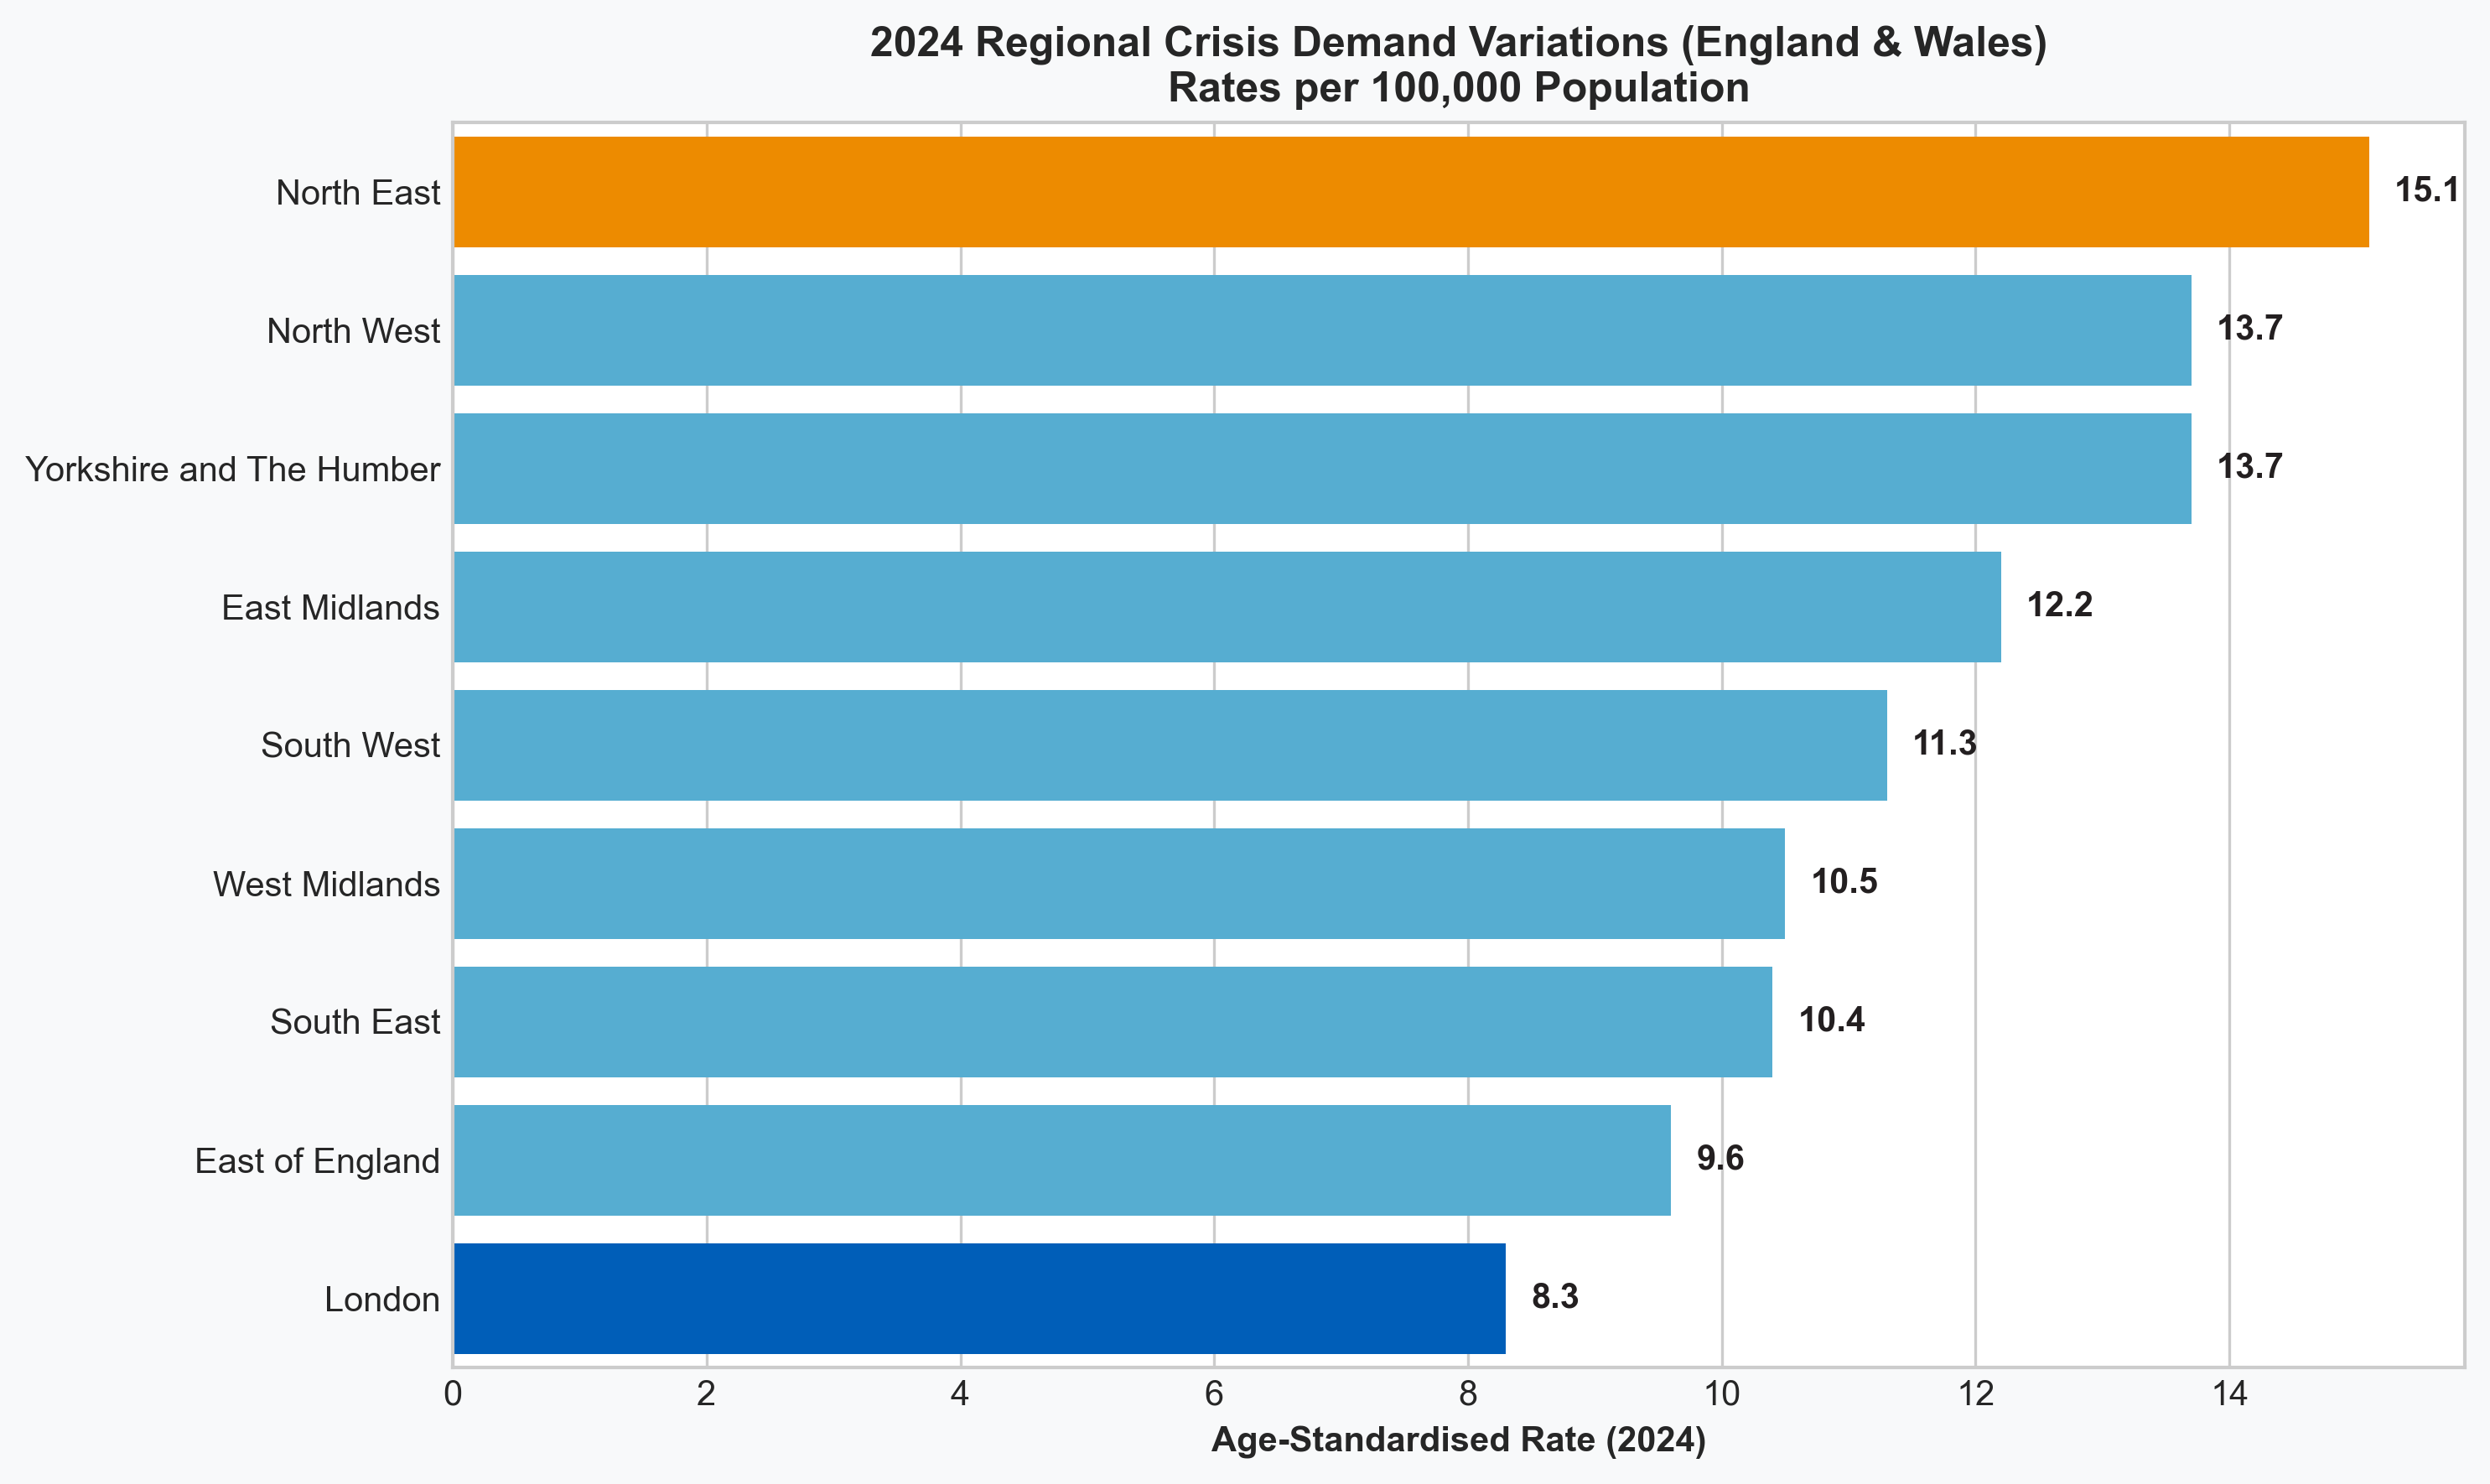


--- TOP REGIONS BY 2024 SUICIDE RATE ---
               Area_Name  2024_Rate 2024_Deaths
              North East       15.1         359
              North West       13.7         916
Yorkshire and The Humber       13.7         680
           East Midlands       12.2         537
              South West       11.3         586


In [29]:
# Regional Analysis & Bar Chart
fig, ax2 = plt.subplots(figsize=(10, 6), dpi=300)
fig.patch.set_facecolor('#F8F9FA')
ax2.set_facecolor('#FFFFFF')

sns.barplot(data=df_regions, x='2024_Rate', y='Area_Name', color=colors['region'], ax=ax2)

ax2.set_title('2024 Regional Crisis Demand Variations (England & Wales)\nRates per 100,000 Population', fontweight='bold')
ax2.set_xlabel('Age-Standardised Rate (2024)', fontweight='bold')
ax2.set_ylabel('')

for i, v in enumerate(df_regions['2024_Rate']):
    ax2.text(v + 0.2, i, str(v), color='#231F20', va='center', fontweight='bold')

ax2.patches[0].set_facecolor('#ED8B00') 
ax2.patches[-1].set_facecolor('#005EB8') 

plt.tight_layout()
plt.savefig('ANA-3_Regional_Bar.png', facecolor=fig.get_facecolor())
plt.show()

print("\n--- TOP REGIONS BY 2024 SUICIDE RATE ---")
print(df_regions[['Area_Name', '2024_Rate', '2024_Deaths']].head(5).to_string(index=False))

In [31]:
# saving cleaned datasets
df_gender[['Year', 'Persons_Rate', 'Males_Rate', 'Females_Rate']].to_csv('Clean_Gender_Trends_2010_2024.csv', index=False)
df_regions[['Area_Name', '2024_Rate', '2024_Deaths']].to_csv('Clean_Regional_Rates_2024.csv', index=False)
print("\n[SUCCESS] Clean datasets saved as CSV files.")


[SUCCESS] Clean datasets saved as CSV files.
